In [1]:
#Importations et configuration
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (confusion_matrix, roc_curve, auc, 
                             precision_recall_curve, f1_score, fbeta_score,
                             classification_report, average_precision_score)
import shap
from Orchestrator import DOSSIER_RACINE, DOSSIER_MODELES, DOSSIER_TF, DOSSIER_TRANSFORMED
import warnings

warnings.filterwarnings('ignore')

I0000 00:00:1775251931.035584   25615 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775251931.095276   25615 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1775251932.622928   25615 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


/home/clement/ProjetML/RN_test/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Rechargement du modèle et des données de test
nom_modele = os.path.join(DOSSIER_MODELES, "baseline_mlp.keras")
model = keras.models.load_model(nom_modele)

test_ds = tf.data.Dataset.load(os.path.join(DOSSIER_TF, 'test'))

def valider_chargement_evaluation(model, dataset):
    input_shape_model = model.input_shape[1]
    for x_batch, y_batch in dataset.take(1):
        input_shape_data = x_batch.shape[1]
        break
    assert input_shape_model == input_shape_data, f"Incohérence dimensionnelle : {input_shape_model} vs {input_shape_data}"
    print(f"Modèle '{model.name}' prêt pour l'inférence sur le jeu de test.")

valider_chargement_evaluation(model, test_ds)

E0000 00:00:1775251935.117010   25615 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Modèle 'Baseline_MLP' prêt pour l'inférence sur le jeu de test.


W0000 00:00:1775251935.117547   25678 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775251935.137162   25615 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


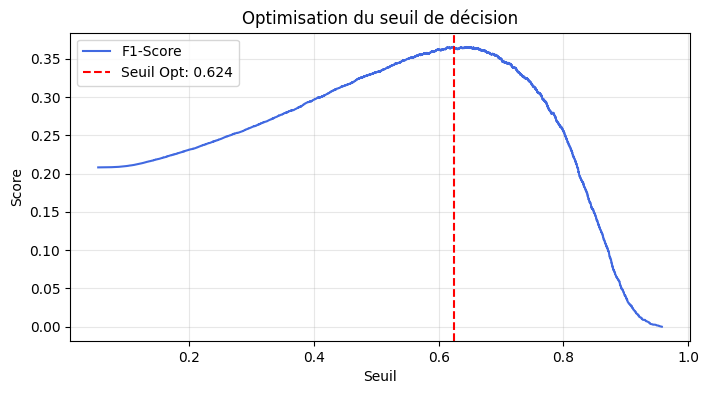

--- Rapport de Classification (Seuil : 0.624) ---
              precision    recall  f1-score   support

         0.0       0.93      0.83      0.88     33855
         1.0       0.28      0.52      0.37      4448

    accuracy                           0.79     38303
   macro avg       0.61      0.67      0.62     38303
weighted avg       0.85      0.79      0.82     38303



In [3]:
#Inférence et recherche du seuil optimal
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_probs = model.predict(test_ds, verbose=0).flatten()

def evaluer_seuil_optimal(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    idx_opt = np.argmax(f1_scores)
    seuil_opt = thresholds[idx_opt] if idx_opt < len(thresholds) else thresholds[-1]
    
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='royalblue')
    plt.axvline(seuil_opt, color='red', linestyle='--', label=f'Seuil Opt: {seuil_opt:.3f}')
    plt.title("Optimisation du seuil de décision")
    plt.xlabel("Seuil")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    y_pred_opt = (y_probs >= seuil_opt).astype(int)
    print(f"--- Rapport de Classification (Seuil : {seuil_opt:.3f}) ---")
    print(classification_report(y_true, y_pred_opt))
    
    return seuil_opt, y_pred_opt

seuil_optimal, y_pred_final = evaluer_seuil_optimal(y_true, y_probs)

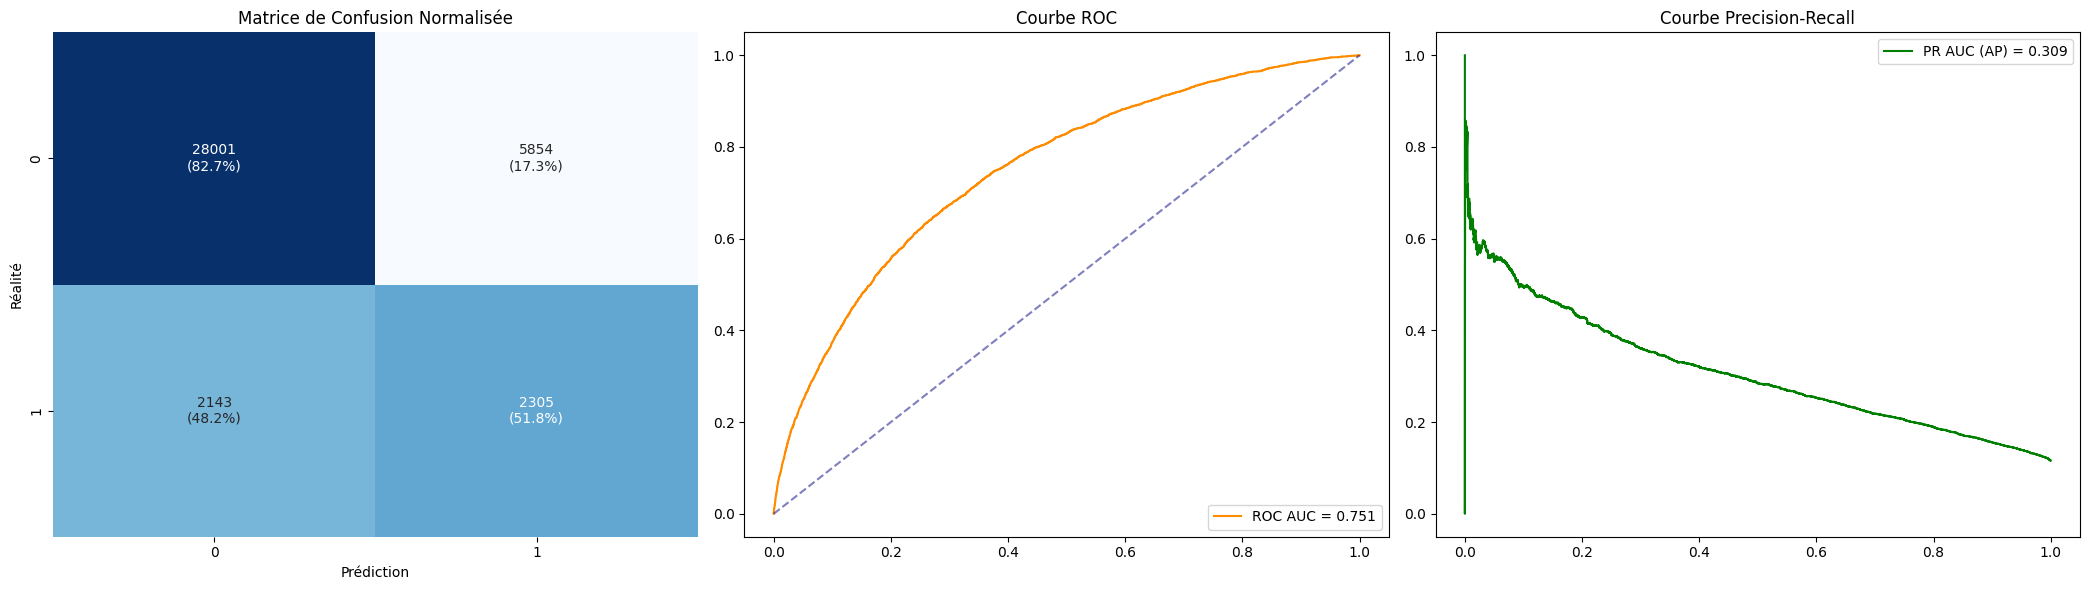

In [4]:
#Analyse visuelle de performance (ROC et PR)
def tracer_performances_completes(y_true, y_probs, y_pred, seuil):
    fig, ax = plt.subplots(1, 3, figsize=(21, 6))
    
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    labels = (np.array(["{0:d}\n({1:.1%})".format(count, pct) 
              for count, pct in zip(cm.flatten(), cm_norm.flatten())])).reshape(2,2)
    
    sns.heatmap(cm_norm, annot=labels, fmt="", cmap='Blues', ax=ax[0], cbar=False)
    ax[0].set_title('Matrice de Confusion Normalisée')
    ax[0].set_xlabel('Prédiction')
    ax[0].set_ylabel('Réalité')
    
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    ax[1].plot(fpr, tpr, label=f'ROC AUC = {auc(fpr, tpr):.3f}', color='darkorange')
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='navy', alpha=0.5)
    ax[1].set_title('Courbe ROC')
    ax[1].legend(loc="lower right")
    
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    ap_score = average_precision_score(y_true, y_probs)
    ax[2].plot(recall, precision, label=f'PR AUC (AP) = {ap_score:.3f}', color='green')
    ax[2].set_title('Courbe Precision-Recall')
    ax[2].legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()

tracer_performances_completes(y_true, y_probs, y_pred_final, seuil_optimal)

Importance globale des variables (Summary Plot) :


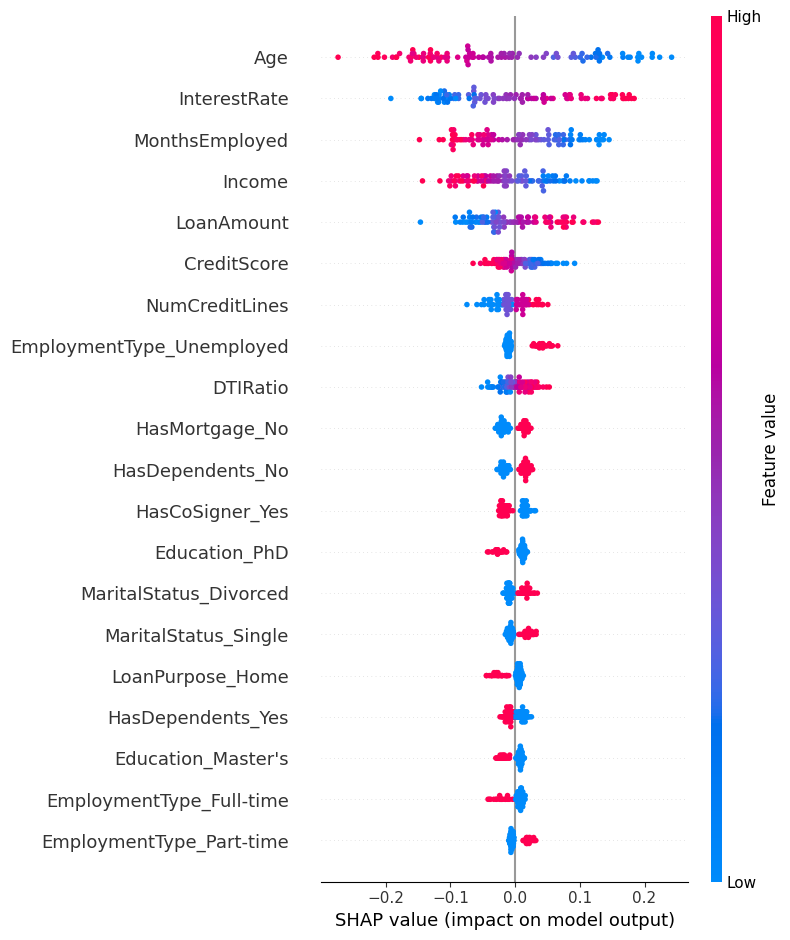

Validation réussie. Résultats sauvegardés : {'ROC_AUC': 0.7511982472063997, 'PR_AUC': 0.309456429833988, 'Seuil_Optimal': 0.6239148378372192, 'F1_Score': 0.3656698659474895}


In [5]:
# 1. Rechargement des noms de caractéristiques
X_train_ref = pd.read_csv(os.path.join(DOSSIER_TRANSFORMED, 'train_transformed.csv'), sep=';').drop(columns=['Default'])
feature_names = X_train_ref.columns.tolist()

# 2. Préparation des données pour SHAP
background = X_train_ref.sample(n=200, random_state=42).values.astype('float32')
X_test_eval = pd.read_csv(os.path.join(DOSSIER_TRANSFORMED, 'test_transformed.csv'), sep=';').drop(columns=['Default'])
X_explain_np = X_test_eval.sample(n=100, random_state=42).values.astype('float32')
X_explain_df = pd.DataFrame(X_explain_np, columns=feature_names)

# 3. Calcul des valeurs SHAP
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_explain_np)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[0]
else:
    shap_values_to_plot = shap_values

if len(shap_values_to_plot.shape) == 3:
    shap_values_to_plot = shap_values_to_plot[:, :, 0]

print("Importance globale des variables (Summary Plot) :")
shap.summary_plot(shap_values_to_plot, X_explain_df, plot_type="dot")

# 4. Correction : Recalcul des métriques pour la sauvegarde (Scope Global)
fpr_global, tpr_global, _ = roc_curve(y_true, y_probs)
ap_score_global = average_precision_score(y_true, y_probs)

metriques_finales = {
    "ROC_AUC": float(auc(fpr_global, tpr_global)),
    "PR_AUC": float(ap_score_global),
    "Seuil_Optimal": float(seuil_optimal),
    "F1_Score": float(f1_score(y_true, y_pred_final))
}

# 5. Exportation en JSON
chemin_metriques = os.path.join(DOSSIER_RACINE, 'performance_finale.json')
with open(chemin_metriques, 'w') as f:
    json.dump(metriques_finales, f)

# 6. Procédure de vérification unitaire
def valider_export_final(chemin):
    """Vérifie l'existence et l'intégrité du fichier de résultats."""
    assert os.path.exists(chemin), f"Erreur : Le fichier {chemin} est introuvable."
    with open(chemin, 'r') as f:
        data = json.load(f)
    for cle in ["ROC_AUC", "PR_AUC", "Seuil_Optimal", "F1_Score"]:
        assert cle in data, f"Erreur : La clé {cle} est manquante dans le fichier."
    print(f"Validation réussie. Résultats sauvegardés : {data}")

valider_export_final(chemin_metriques)

In [6]:
# Exportation en JSON dans le sous-dossier
chemin_metriques = os.path.join(DOSSIER_RACINE, 'performance_finale.json')
with open(chemin_metriques, 'w') as f:
    json.dump(metriques_finales, f, indent=2)